In [1]:
#Library Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [ ]:
#Load Dataset
df = pd.read_csv("../data/processed_stock_data.csv")

df.head()

,Date,Unnamed: 0,Close,High,Low,Open,Volume,Returns,MA20,MA50,...,return_lag_5,rolling_mean_10,rolling_mean_30,momentum_5,momentum_10,momentum_30,day_of_week,month,quarter,target
0,2010-03-16,49,86.877113,86.959201,86.190510,86.429327,168673000,0.007966,84.156820,83.279019,...,0.001662,85.503896,82.955024,0.017037,0.037523,0.067394,1,3,1,1
1,2010-03-17,50,87.392036,87.675635,86.884550,87.138296,177468100,0.005927,84.412056,83.335290,...,0.004456,85.862122,83.122196,0.018526,0.042743,0.060881,2,3,1,0
2,2010-03-18,51,87.347275,87.518921,86.996512,87.399516,196509100,-0.000512,84.640797,83.386189,...,0.004175,86.190495,83.301558,0.013773,0.039062,0.065647,3,3,1,0
3,2010-03-19,52,86.905121,87.894297,86.567898,86.905121,226641100,-0.005062,84.838849,83.427050,...,0.000087,86.354500,83.550513,0.008553,0.019235,0.094021,4,3,1,1
4,2010-03-22,53,87.369728,87.527102,86.358072,86.410528,184477800,0.005346,85.059385,83.470038,...,0.000260,86.563472,83.809483,0.013681,0.024504,0.097601,0,3,1,1


In [ ]:
#Check for Missing Values
df.isnull().sum()

Date               0
Unnamed: 0         0
Close              0
High               0
Low                0
Open               0
Volume             0
Returns            0
MA20               0
MA50               0
Volatility         0
daily_return       0
log_return         0
price_change       0
high_low_range     0
close_position     0
SMA_20             0
SMA_50             0
EMA_20             0
EMA_50             0
MA_difference      0
RSI                0
MACD               0
MACD_signal        0
MACD_difference    0
BB_high            0
BB_low             0
BB_middle          0
BB_width           0
ATR                0
Volume_SMA_20      0
volume_change      0
return_lag_1       0
return_lag_2       0
return_lag_5       0
rolling_mean_10    0
rolling_mean_30    0
momentum_5         0
momentum_10        0
momentum_30        0
day_of_week        0
month              0
quarter            0
target             0
dtype: int64

In [ ]:
#Remove Remaining Missing Values
df = df.dropna().reset_index(drop=True)

In [6]:
#Create Target Variable
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df = df[:-1]


In [ ]:
#Select Features
features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Returns',
    'MA20',
    'MA50',
    'Volatility',
    'daily_return',
    'log_return',
    'price_change',
    'high_low_range',
    'close_position',
    'SMA_20',
    'SMA_50',
    'EMA_20',
    'EMA_50',
    'MA_difference',
    'RSI',
    'MACD',
    'MACD_signal',
    'MACD_difference',
    'BB_high',
    'BB_low',
    'BB_middle',
    'BB_width',
    'ATR',
    'Volume_SMA_20',
    'volume_change',
    'return_lag_1',
    'return_lag_2',
    'return_lag_5',
    'rolling_mean_10',
    'rolling_mean_30',
    'momentum_5',
    'momentum_10',
    'momentum_30',
    'day_of_week',
    'month',
    'quarter'
]
X = df[features]
y = df["Target"]

In [10]:
df[['target', 'Target']].head(10)

,target,Target
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,0,0
8,1,1
9,1,1


In [11]:
df = df.drop(columns=['target'])

In [12]:
#Train-Test Split
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
#Scale Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
#Train Logistic Regression Model
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
#Logistic Predictions
log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [16]:
#Logistic Evaluation
print(classification_report(y_test, log_pred))

print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.51      0.06      0.10       351
           1       0.53      0.95      0.68       394

    accuracy                           0.53       745
   macro avg       0.52      0.50      0.39       745
weighted avg       0.52      0.53      0.41       745

Accuracy : 0.5302013422818792
Precision: 0.5311614730878187
Recall   : 0.9517766497461929
F1 Score : 0.6818181818181818


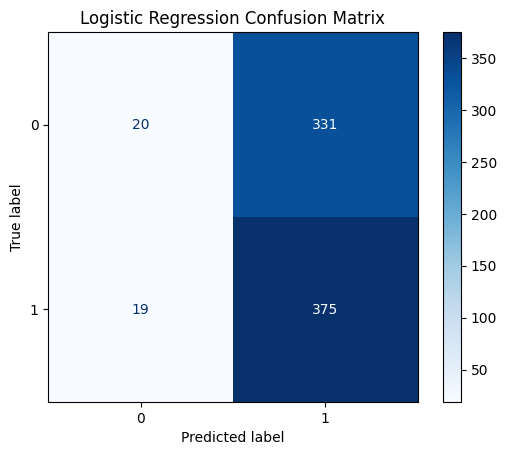

In [17]:
#Confusion Matrix
cm = confusion_matrix(y_test, log_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

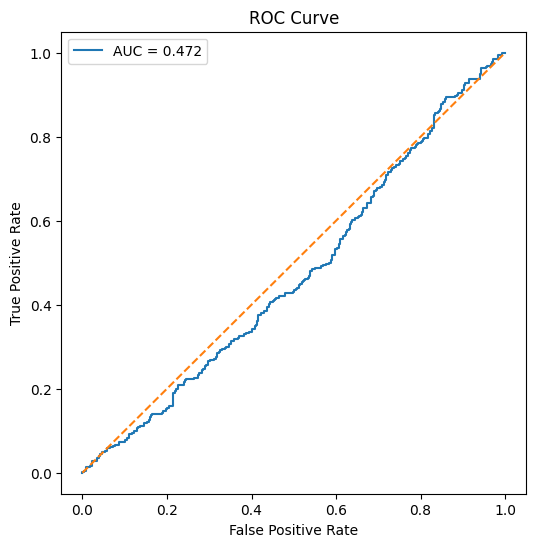

In [18]:
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, log_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, log_prob):.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [19]:
#Train Decision Tree Model
tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [20]:
#Decision Tree Evaluation
tree_pred = tree.predict(X_test)

print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.47      0.28      0.35       351
           1       0.53      0.72      0.61       394

    accuracy                           0.51       745
   macro avg       0.50      0.50      0.48       745
weighted avg       0.50      0.51      0.49       745



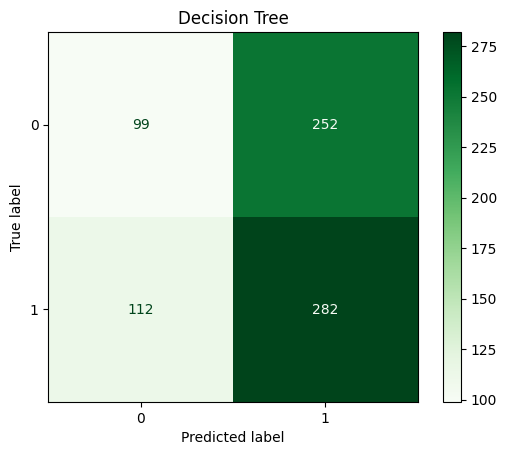

In [21]:
#DT Confusion Matrix
cm = confusion_matrix(y_test, tree_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Greens")

plt.title("Decision Tree")

plt.show()

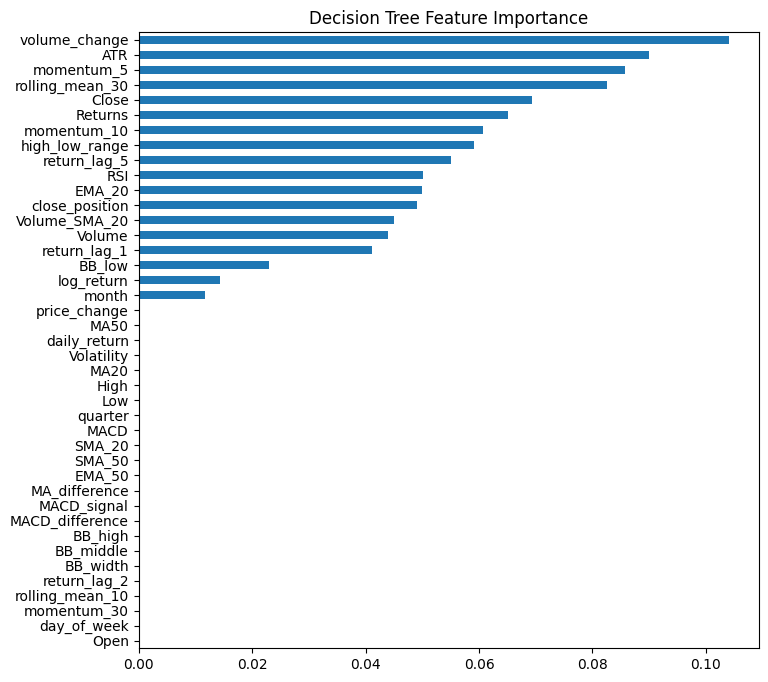

In [22]:
#Feature Importance
importance = pd.Series(
    tree.feature_importances_,
    index=features
).sort_values()
importance.plot(kind="barh", figsize=(8,8))

plt.title("Decision Tree Feature Importance")

plt.show()

In [23]:
#Train Random Forest Model
forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
#RF Evaluation
forest_pred = forest.predict(X_test)

forest_prob = forest.predict_proba(X_test)[:,1]

print(classification_report(y_test, forest_pred))

              precision    recall  f1-score   support

           0       0.43      0.45      0.44       351
           1       0.49      0.48      0.49       394

    accuracy                           0.46       745
   macro avg       0.46      0.46      0.46       745
weighted avg       0.47      0.46      0.46       745



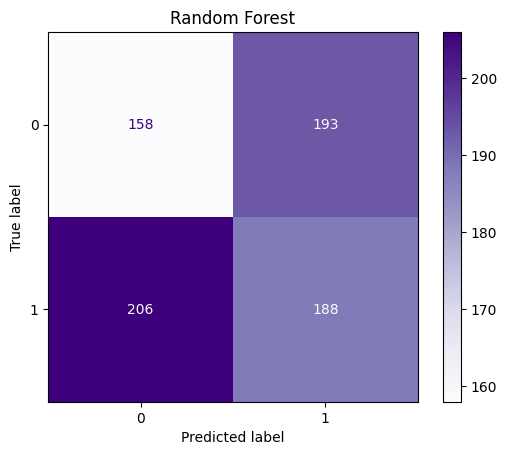

In [25]:
#RF Confusion Matrix
cm = confusion_matrix(y_test, forest_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Purples")

plt.title("Random Forest")

plt.show()

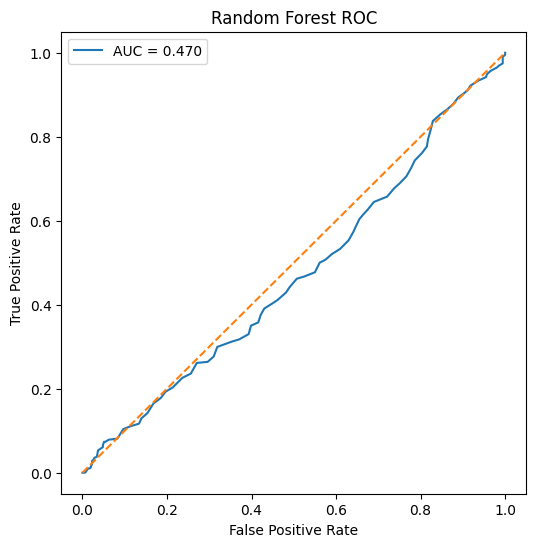

In [26]:
#RF ROC Curve
fpr, tpr, _ = roc_curve(y_test, forest_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, forest_prob):.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC")

plt.legend()

plt.show()

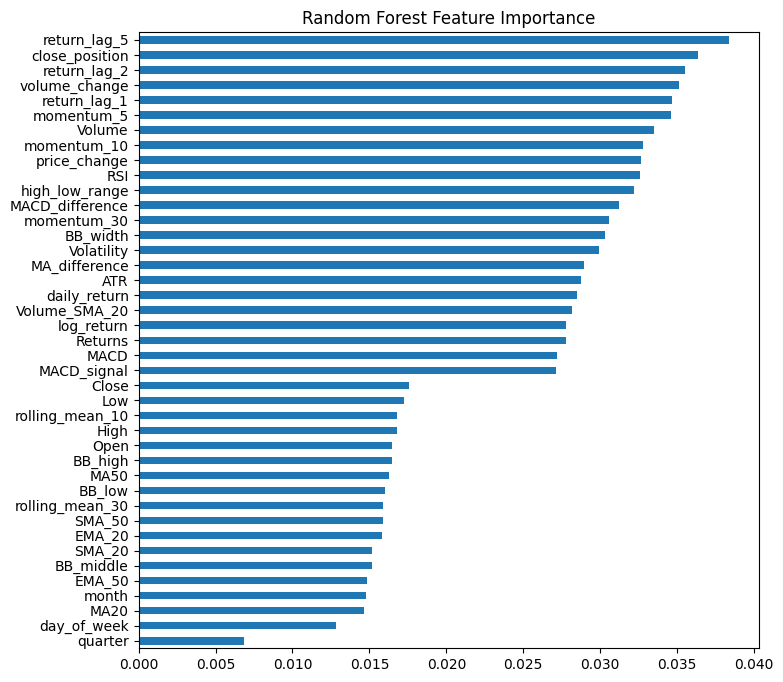

In [27]:
#RF Feature Importance
importance = pd.Series(
    forest.feature_importances_,
    index=features
).sort_values()

importance.plot(
    kind="barh",
    figsize=(8,8)
)

plt.title("Random Forest Feature Importance")

plt.show()

In [ ]:
#Compare Model Performance
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, forest_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, forest_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, forest_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.530201,0.531161,0.951777,0.681818
1,Decision Tree,0.511409,0.528090,0.715736,0.607759
2,Random Forest,0.464430,0.493438,0.477157,0.485161


In [29]:
#Best Model
results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.530201,0.531161,0.951777,0.681818
1,Decision Tree,0.511409,0.528090,0.715736,0.607759
2,Random Forest,0.464430,0.493438,0.477157,0.485161


In [30]:
results.to_csv("../results/DAY3/model_evaluation.csv", index=False)